In [3]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.4 MB/s eta 0:00:00


2.11

Price index: 83.46 / 100


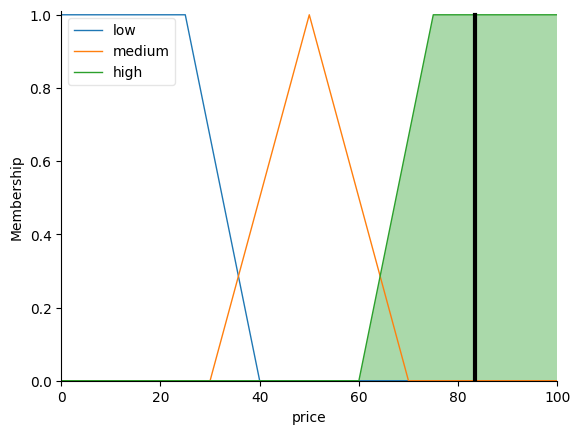

In [11]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

distance = ctrl.Antecedent(np.arange(0, 51, 1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
weather = ctrl.Antecedent(np.arange(0, 11, 1), 'weather')
demand = ctrl.Antecedent(np.arange(0, 101, 1), 'demand')
driver_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'driver_rating')
punctuality = ctrl.Antecedent(np.arange(0, 101, 1), 'punctuality')
price = ctrl.Consequent(np.arange(0, 101, 1), 'price')

distance['short'] = fuzz.trapmf(distance.universe, [0, 0, 3, 8])
distance['medium'] = fuzz.trimf(distance.universe, [5, 12, 20])
distance['long'] = fuzz.trapmf(distance.universe, [15, 25, 50, 50])

traffic['low'] = fuzz.trapmf(traffic.universe, [0, 0, 20, 35])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 70])
traffic['high'] = fuzz.trapmf(traffic.universe, [60, 75, 100, 100])

weather['good'] = fuzz.trapmf(weather.universe, [0, 0, 2, 4])
weather['moderate'] = fuzz.trimf(weather.universe, [2, 5, 7])
weather['bad'] = fuzz.trapmf(weather.universe, [6, 8, 10, 10])

demand['low'] = fuzz.trapmf(demand.universe, [0, 0, 20, 35])
demand['medium'] = fuzz.trimf(demand.universe, [20, 50, 70])
demand['high'] = fuzz.trapmf(demand.universe, [60, 75, 100, 100])

driver_rating['poor'] = fuzz.trapmf(driver_rating.universe, [0, 0, 2, 3])
driver_rating['moderate'] = fuzz.trimf(driver_rating.universe, [2, 3, 4])
driver_rating['good'] = fuzz.trapmf(driver_rating.universe, [3.5, 4.5, 5, 5])

punctuality['late'] = fuzz.trapmf(punctuality.universe, [0, 0, 30, 50])
punctuality['average'] = fuzz.trimf(punctuality.universe, [30, 55, 75])
punctuality['on_time'] = fuzz.trapmf(punctuality.universe, [60, 75, 100, 100])

price['low'] = fuzz.trapmf(price.universe, [0, 0, 25, 40])
price['medium'] = fuzz.trimf(price.universe, [30, 50, 70])
price['high'] = fuzz.trapmf(price.universe, [60, 75, 100, 100])

rules = [
    ctrl.Rule(distance['short'] & traffic['low'], price['low']),
    ctrl.Rule(distance['short'] & traffic['medium'], price['medium']),
    ctrl.Rule(distance['short'] & traffic['high'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['low'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['medium'], price['medium']),
    ctrl.Rule(distance['medium'] & traffic['high'], price['high']),
    ctrl.Rule(distance['long'] & traffic['low'], price['medium']),
    ctrl.Rule(distance['long'] & traffic['medium'], price['high']),
    ctrl.Rule(distance['long'] & traffic['high'], price['high']),
    ctrl.Rule(weather['bad'] & demand['high'], price['high']),
    ctrl.Rule(weather['bad'] & demand['medium'], price['medium']),
    ctrl.Rule(weather['good'] & demand['low'], price['low']),
    ctrl.Rule(demand['high'] & traffic['high'], price['high']),
    ctrl.Rule(demand['low'] & traffic['low'], price['low']),
    ctrl.Rule(driver_rating['good'] & punctuality['on_time'], price['medium']),
    ctrl.Rule(driver_rating['poor'] & punctuality['late'], price['low']),
]

sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

sim.input['distance'] = 8
sim.input['traffic'] = 85
sim.input['weather'] = 8
sim.input['demand'] = 90
sim.input['driver_rating'] = 4.2
sim.input['punctuality'] = 60

sim.compute()
print(f"Price index: {sim.output['price']:.2f} / 100")
price.view(sim=sim)

2.12


Discount index: 83.46 / 100


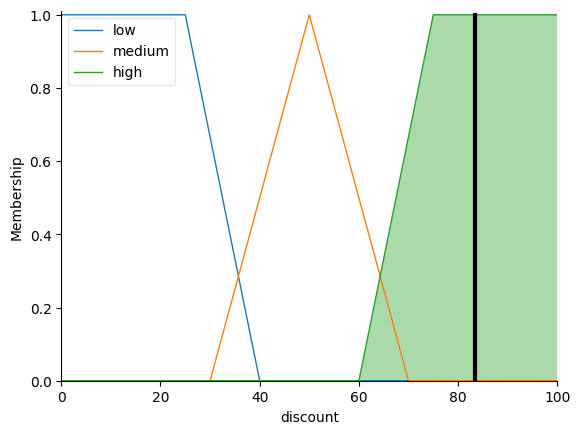

In [12]:
purchase_freq = ctrl.Antecedent(np.arange(0, 101, 1), 'purchase_freq')
order_value = ctrl.Antecedent(np.arange(0, 101, 1), 'order_value')
customer_rank = ctrl.Antecedent(np.arange(0, 101, 1), 'customer_rank')
competition = ctrl.Antecedent(np.arange(0, 101, 1), 'competition')
discount = ctrl.Consequent(np.arange(0, 101, 1), 'discount')

purchase_freq['low'] = fuzz.trapmf(purchase_freq.universe, [0, 0, 20, 35])
purchase_freq['medium'] = fuzz.trimf(purchase_freq.universe, [20, 50, 70])
purchase_freq['high'] = fuzz.trapmf(purchase_freq.universe, [60, 75, 100, 100])

order_value['low'] = fuzz.trapmf(order_value.universe, [0, 0, 20, 35])
order_value['medium'] = fuzz.trimf(order_value.universe, [20, 50, 70])
order_value['high'] = fuzz.trapmf(order_value.universe, [60, 75, 100, 100])

customer_rank['low'] = fuzz.trapmf(customer_rank.universe, [0, 0, 20, 35])
customer_rank['medium'] = fuzz.trimf(customer_rank.universe, [20, 50, 70])
customer_rank['high'] = fuzz.trapmf(customer_rank.universe, [60, 75, 100, 100])

competition['low'] = fuzz.trapmf(competition.universe, [0, 0, 20, 35])
competition['medium'] = fuzz.trimf(competition.universe, [20, 50, 70])
competition['high'] = fuzz.trapmf(competition.universe, [60, 75, 100, 100])

discount['low'] = fuzz.trapmf(discount.universe, [0, 0, 25, 40])
discount['medium'] = fuzz.trimf(discount.universe, [30, 50, 70])
discount['high'] = fuzz.trapmf(discount.universe, [60, 75, 100, 100])

rules = [
    ctrl.Rule(purchase_freq['high'] & order_value['high'], discount['high']),
    ctrl.Rule(purchase_freq['high'] & order_value['medium'], discount['medium']),
    ctrl.Rule(purchase_freq['high'] & order_value['low'], discount['medium']),
    ctrl.Rule(purchase_freq['medium'] & order_value['high'], discount['medium']),
    ctrl.Rule(purchase_freq['medium'] & order_value['medium'], discount['medium']),
    ctrl.Rule(purchase_freq['medium'] & order_value['low'], discount['low']),
    ctrl.Rule(purchase_freq['low'] & order_value['high'], discount['medium']),
    ctrl.Rule(purchase_freq['low'] & order_value['medium'], discount['low']),
    ctrl.Rule(purchase_freq['low'] & order_value['low'], discount['low']),
    ctrl.Rule(customer_rank['high'] & competition['high'], discount['high']),
    ctrl.Rule(customer_rank['high'] & competition['low'], discount['medium']),
    ctrl.Rule(customer_rank['low'] & competition['high'], discount['medium']),
    ctrl.Rule(customer_rank['low'] & competition['low'], discount['low']),
    ctrl.Rule(competition['high'] & order_value['high'], discount['high']),
    ctrl.Rule(competition['low'] & purchase_freq['low'], discount['low']),
]

sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

sim.input['purchase_freq'] = 75
sim.input['order_value'] = 80
sim.input['customer_rank'] = 70
sim.input['competition'] = 85

sim.compute()
print(f"Discount index: {sim.output['discount']:.2f} / 100")
discount.view(sim=sim)

2.13

Discount: 67.09 / 100


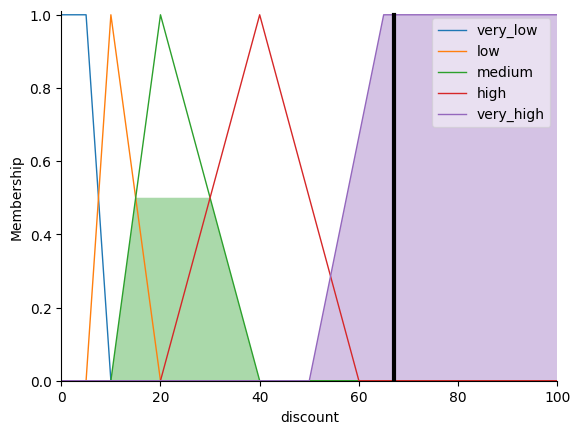

In [9]:
store_rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'store_rating')
sales_volume = ctrl.Antecedent(np.arange(0, 101, 1), 'sales_volume')
profit_margin = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_margin')
seasonal_event = ctrl.Antecedent(np.arange(0, 101, 1), 'seasonal_event')
competitor_disc = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor_disc')
discount = ctrl.Consequent(np.arange(0, 101, 1), 'discount')

store_rating['low'] = fuzz.trapmf(store_rating.universe, [0, 0, 3.5, 4.0])
store_rating['medium'] = fuzz.trimf(store_rating.universe, [3.5, 4.25, 4.5])
store_rating['high'] = fuzz.trapmf(store_rating.universe, [4.0, 4.5, 5.0, 5.0])

sales_volume['low'] = fuzz.trapmf(sales_volume.universe, [0, 0, 20, 35])
sales_volume['medium'] = fuzz.trimf(sales_volume.universe, [20, 50, 70])
sales_volume['high'] = fuzz.trapmf(sales_volume.universe, [60, 75, 100, 100])

profit_margin['low'] = fuzz.trapmf(profit_margin.universe, [0, 0, 20, 35])
profit_margin['medium'] = fuzz.trimf(profit_margin.universe, [20, 50, 70])
profit_margin['high'] = fuzz.trapmf(profit_margin.universe, [60, 75, 100, 100])

seasonal_event['none'] = fuzz.trapmf(seasonal_event.universe, [0, 0, 15, 30])
seasonal_event['moderate'] = fuzz.trimf(seasonal_event.universe, [20, 50, 70])
seasonal_event['high'] = fuzz.trapmf(seasonal_event.universe, [60, 75, 100, 100])

competitor_disc['low'] = fuzz.trapmf(competitor_disc.universe, [0, 0, 20, 35])
competitor_disc['medium'] = fuzz.trimf(competitor_disc.universe, [20, 50, 70])
competitor_disc['high'] = fuzz.trapmf(competitor_disc.universe, [60, 75, 100, 100])

discount['very_low'] = fuzz.trapmf(discount.universe, [0, 0, 5, 10])
discount['low'] = fuzz.trimf(discount.universe, [5, 10, 20])
discount['medium'] = fuzz.trimf(discount.universe, [10, 20, 40])
discount['high'] = fuzz.trimf(discount.universe, [20, 40, 60])
discount['very_high'] = fuzz.trapmf(discount.universe, [50, 65, 100, 100])

rules = [
    ctrl.Rule(store_rating['high'] & sales_volume['high'] & profit_margin['high'], discount['very_low']),
    ctrl.Rule(store_rating['low'] & sales_volume['low'] & profit_margin['high'], discount['high']),
    ctrl.Rule(seasonal_event['high'] & competitor_disc['high'], discount['very_high']),
    ctrl.Rule(store_rating['medium'] & sales_volume['medium'] & profit_margin['medium'], discount['medium']),
    ctrl.Rule(competitor_disc['low'] & profit_margin['low'] & sales_volume['high'], discount['very_low']),
    ctrl.Rule(competitor_disc['high'] & profit_margin['high'], discount['high']),
    ctrl.Rule(seasonal_event['none'] & profit_margin['high'], discount['low']),
]

sim = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules))

sim.input['store_rating'] = 4.2
sim.input['sales_volume'] = 40
sim.input['profit_margin'] = 60
sim.input['seasonal_event'] = 80
sim.input['competitor_disc'] = 75

sim.compute()
print(f"Discount: {sim.output['discount']:.2f} / 100")
discount.view(sim=sim)

2.14


Orders to combine: 62.44 / 100
Delivery priority: 82.38 / 100


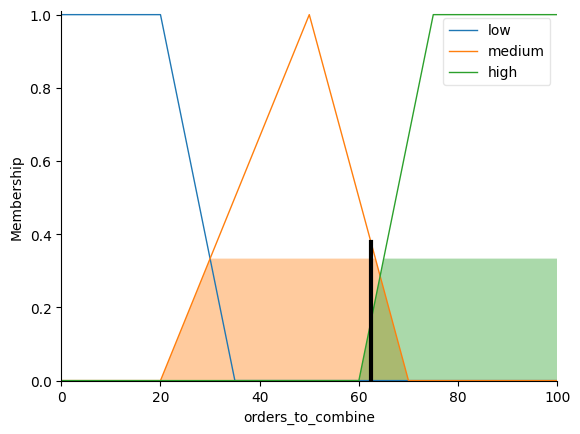

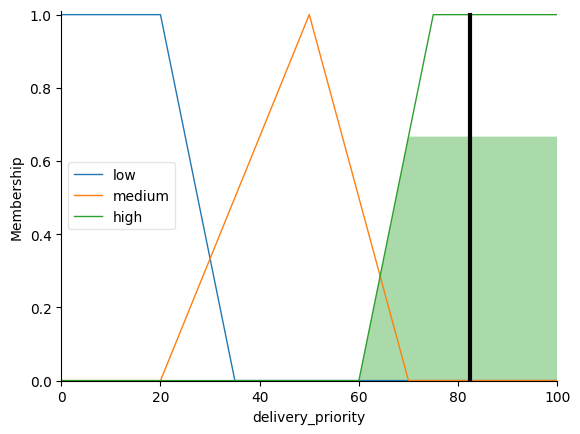

In [10]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

order_density = ctrl.Antecedent(np.arange(0, 101, 1), 'order_density')
delivery_urgency = ctrl.Antecedent(np.arange(0, 101, 1), 'delivery_urgency')
driver_load = ctrl.Antecedent(np.arange(0, 101, 1), 'driver_load')
traffic = ctrl.Antecedent(np.arange(0, 101, 1), 'traffic')
profit_per_trip = ctrl.Antecedent(np.arange(0, 101, 1), 'profit_per_trip')
orders_to_combine = ctrl.Consequent(np.arange(0, 101, 1), 'orders_to_combine')
delivery_priority = ctrl.Consequent(np.arange(0, 101, 1), 'delivery_priority')

for var in [order_density, delivery_urgency, driver_load, traffic, profit_per_trip, orders_to_combine, delivery_priority]:
    var['low'] = fuzz.trapmf(var.universe, [0, 0, 20, 35])
    var['medium'] = fuzz.trimf(var.universe, [20, 50, 70])
    var['high'] = fuzz.trapmf(var.universe, [60, 75, 100, 100])

rules_combine = [
    ctrl.Rule(order_density['high'] & traffic['low'], orders_to_combine['high']),
    ctrl.Rule(order_density['high'] & traffic['medium'], orders_to_combine['medium']),
    ctrl.Rule(order_density['medium'] & traffic['low'], orders_to_combine['medium']),
    ctrl.Rule(order_density['low'], orders_to_combine['low']),
    ctrl.Rule(driver_load['high'] & order_density['high'], orders_to_combine['high']),
    ctrl.Rule(traffic['high'], orders_to_combine['low']),
]

rules_priority = [
    ctrl.Rule(delivery_urgency['high'] & profit_per_trip['high'], delivery_priority['high']),
    ctrl.Rule(delivery_urgency['high'] & profit_per_trip['low'], delivery_priority['medium']),
    ctrl.Rule(delivery_urgency['low'] & profit_per_trip['high'], delivery_priority['medium']),
    ctrl.Rule(delivery_urgency['low'] & profit_per_trip['low'], delivery_priority['low']),
    ctrl.Rule(driver_load['low'] & profit_per_trip['high'], delivery_priority['high']),
    ctrl.Rule(traffic['high'] & delivery_urgency['high'], delivery_priority['medium']),
]

sim_combine = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules_combine))
sim_priority = ctrl.ControlSystemSimulation(ctrl.ControlSystem(rules_priority))

sim_combine.input['order_density'] = 75
sim_combine.input['traffic'] = 30
sim_combine.input['driver_load'] = 60

sim_priority.input['delivery_urgency'] = 80
sim_priority.input['profit_per_trip'] = 70
sim_priority.input['driver_load'] = 60
sim_priority.input['traffic'] = 30

sim_combine.compute()
sim_priority.compute()

print(f"Orders to combine: {sim_combine.output['orders_to_combine']:.2f} / 100")
print(f"Delivery priority: {sim_priority.output['delivery_priority']:.2f} / 100")
orders_to_combine.view(sim=sim_combine)
delivery_priority.view(sim=sim_priority)